In [19]:
# ==============================================================================
# KAGGLE SETUP BLOCK (INDEPENDENT BLOCK)
# ==============================================================================
import os
import sys
import subprocess
from pathlib import Path

# Detect Kaggle environment
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if IS_KAGGLE:
    print("--- Detected Kaggle Environment ---")
    
    # 1. Clone repository if not present
    REPO_URL = "https://github.com/HCMUS-VIR-Nhom8/DINOv3-FAISS-HNSW-SOP-VisualProductSearch.git"
    REPO_DIR = Path("/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch")
    
    if not REPO_DIR.exists():
        print(f"Cloning repository: {REPO_URL}")
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

    # swich to branch "experiments"
    print("Switching to branch: experiments")
    try:
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", "experiments"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error switching branch: {e}. Attempting to fetch first...")
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", "experiments"], check=True)
    
    # Change working directory of the kernel to notebooks directory
    # so that PROJECT_ROOT = Path("..").resolve() works correctly
    NOTEBOOKS_DIR = REPO_DIR / "notebooks"
    if NOTEBOOKS_DIR.exists():
        os.chdir(str(NOTEBOOKS_DIR))
        print(f"Changed working directory to: {os.getcwd()}")
        
    # Add project root to sys.path so src imports work
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
        print("Added repository root to python path.")
        
    # 2. Download and unzip dataset from Google Drive
    DATA_DIR = REPO_DIR / "data" / "raw" / "Stanford_Online_Products"
    ZIP_PATH = REPO_DIR / "Stanford_Online_Products.zip"
    
    if not DATA_DIR.exists() or not (DATA_DIR / "Ebay_train.txt").exists():
        print("Dataset not found. Downloading from Google Drive...")
        
        # Install gdown if needed
        try:
            import gdown
        except ImportError:
            print("Installing gdown...")
            subprocess.run([sys.executable, "-m", "pip", "install", "gdown"], check=True)
            import gdown
            
        # Download Stanford Online Products ZIP
        file_id = "1TclrpQOF_ullUP99wk_gjGN8pKvtErG8"
        url = f"https://drive.google.com/uc?id={file_id}"
        print(f"Downloading from Google Drive ID: {file_id}")
        gdown.download(url, str(ZIP_PATH), quiet=False)
        
        # Extract the zip file
        print("Extracting dataset...")
        import zipfile
        raw_dir = REPO_DIR / "data" / "raw"
        raw_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(str(ZIP_PATH), 'r') as zip_ref:
            zip_ref.extractall(str(raw_dir))
            
        print("Dataset extraction completed.")
        
        # Clean up zip file
        if ZIP_PATH.exists():
            ZIP_PATH.unlink()
            print("Cleaned up ZIP file.")
            
    # Note on HF login for gated DINOv3 model
    print("\n--- Hugging Face Access Note ---")
    print("DINOv3 is a gated Hugging Face model. If access token is required, run:")
    print("from huggingface_hub import login; login(token='YOUR_HF_TOKEN')\n")
else:
    print("Running in local environment. Setup skipped.")


--- Detected Kaggle Environment ---
Switching to branch: experiments
Branch 'experiments' set up to track remote branch 'experiments' from 'origin'.
Changed working directory to: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/notebooks

--- Hugging Face Access Note ---
DINOv3 is a gated Hugging Face model. If access token is required, run:
from huggingface_hub import login; login(token='YOUR_HF_TOKEN')



Switched to a new branch 'experiments'


# Notebook 01 — SOP Stratified Sampling: 120K → 20K

## Mục tiêu

Notebook này **chỉ thực hiện sampling**, không chạy model/retrieval.

Pipeline:

`SOP 120K → đọc metadata → kiểm tra phân bố → lọc class hợp lệ → stratified sampling → kiểm tra tính đại diện → lưu sop_20k.csv`

Sau notebook này, output chính là:

```text
data/sampled/sop_20k.csv
```

Ngoài ra tạo:

```text
outputs/sampling/
├── class_distribution.csv
├── sampling_summary.json
├── sampling_distribution.png
└── sample_preview.png
```

### Nguyên tắc

- Stratify theo `class_id` vì đây là **product identity** dùng làm ground-truth retrieval.
- Không lấy random 20K đơn thuần.
- Ưu tiên giữ tỷ lệ xuất hiện của các class.
- Chỉ giữ class có ít nhất 2 ảnh để có thể tạo query/gallery ở bước evaluation.
- Không thay đổi `class_id`, `super_class_id`, `image_id` và `path`.

## Cell 1 — Cấu hình experiment

In [20]:
from pathlib import Path

# =========================
# USER CONFIGURATION
# =========================

# Nếu chạy notebook trong repo:
PROJECT_ROOT = Path("..").resolve()
print(PROJECT_ROOT)

# Nếu notebook nằm trong visual_product_search/notebooks/
SOP_ROOT = PROJECT_ROOT / "data" / "raw" / "Stanford_Online_Products"

TRAIN_FILE = SOP_ROOT / "Ebay_train.txt"
TEST_FILE = SOP_ROOT / "Ebay_test.txt"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "sampling"
SPLIT_DIR = PROJECT_ROOT / "data" / "sampled"

SAMPLE_N = 20_000
RANDOM_SEED = 42

# Có kiểm tra image tồn tại hay không.
CHECK_IMAGE_EXISTS = True

# Nếu True: chỉ lấy class có >= 2 ảnh.
# Khuyến nghị giữ True cho retrieval experiment.
REQUIRE_MIN_2_IMAGES_PER_CLASS = True

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SOP_ROOT:", SOP_ROOT)
print("SAMPLE_N:", SAMPLE_N)
print("RANDOM_SEED:", RANDOM_SEED)

/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch
PROJECT_ROOT: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch
SOP_ROOT: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/data/raw/Stanford_Online_Products
SAMPLE_N: 20000
RANDOM_SEED: 42


## Cell 2 — Import thư viện

In [21]:
import json
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.0.2
Pandas: 2.3.3


## Cell 3 — Kiểm tra file SOP

In [22]:
print("Train metadata:", TRAIN_FILE)
print("Test metadata :", TEST_FILE)

print("\nTrain exists:", TRAIN_FILE.exists())
print("Test exists :", TEST_FILE.exists())

if not TRAIN_FILE.exists() or not TEST_FILE.exists():
    raise FileNotFoundError(
        "Không tìm thấy Ebay_train.txt/Ebay_test.txt. "
        "Hãy kiểm tra SOP_ROOT ở Cell 1."
    )

Train metadata: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/data/raw/Stanford_Online_Products/Ebay_train.txt
Test metadata : /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/data/raw/Stanford_Online_Products/Ebay_test.txt

Train exists: True
Test exists : True


## Cell 4 — Đọc `Ebay_train.txt` và `Ebay_test.txt`

Theo format SOP:

```text
image_id class_id super_class_id path
```

Ví dụ:

```text
1 1 1 bicycle_final/111085122871_0.JPG
```

Ta giữ nguyên metadata gốc và thêm `source_split`.

In [23]:
def read_sop_metadata(txt_path, source_split):
    rows = []

    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = line.split(maxsplit=3)

            if len(parts) != 4:
                print(f"Warning: malformed line {line_no}: {line}")
                continue

            image_id, class_id, super_class_id, path = parts
            if not image_id.isdigit():
                continue

            rows.append({
                "image_id": int(image_id),
                "class_id": int(class_id),
                "super_class_id": int(super_class_id),
                "path": path,
                "source_split": source_split,
            })

    return pd.DataFrame(rows)


train_df = read_sop_metadata(TRAIN_FILE, "train")
test_df = read_sop_metadata(TEST_FILE, "test")

print("Train:", train_df.shape)
print("Test :", test_df.shape)

display(train_df.head())

Train: (59551, 5)
Test : (60502, 5)


,image_id,class_id,super_class_id,path,source_split
0,1,1,1,bicycle_final/111085122871_0.JPG,train
1,2,1,1,bicycle_final/111085122871_1.JPG,train
2,3,1,1,bicycle_final/111085122871_2.JPG,train
3,4,1,1,bicycle_final/111085122871_3.JPG,train
4,5,1,1,bicycle_final/111085122871_4.JPG,train


## Cell 5 — Gộp metadata

In [24]:
full_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Total images:", len(full_df))
print("Unique image IDs:", full_df.image_id.nunique())
print("Unique product classes:", full_df.class_id.nunique())
print("Unique super classes:", full_df.super_class_id.nunique())

display(full_df.head())

Total images: 120053
Unique image IDs: 120053
Unique product classes: 22634
Unique super classes: 12


,image_id,class_id,super_class_id,path,source_split
0,1,1,1,bicycle_final/111085122871_0.JPG,train
1,2,1,1,bicycle_final/111085122871_1.JPG,train
2,3,1,1,bicycle_final/111085122871_2.JPG,train
3,4,1,1,bicycle_final/111085122871_3.JPG,train
4,5,1,1,bicycle_final/111085122871_4.JPG,train


## Cell 6 — Kiểm tra duplicate metadata

In [25]:
print("Duplicate image_id:",
      full_df.image_id.duplicated().sum())

print("Duplicate path:",
      full_df.path.duplicated().sum())

# Kiểm tra một image_id có bị gán nhiều class không.
class_per_image = full_df.groupby("image_id")["class_id"].nunique()

print(
    "Image IDs with multiple class_id:",
    (class_per_image > 1).sum()
)

Duplicate image_id: 0
Duplicate path: 0
Image IDs with multiple class_id: 0


## Cell 7 — Tạo absolute image path

In [26]:
full_df["image_path"] = full_df["path"].map(
    lambda p: str(SOP_ROOT / p)
)

display(
    full_df[
        ["image_id", "class_id", "super_class_id",
         "path", "image_path", "source_split"]
    ].head()
)

,image_id,class_id,super_class_id,path,image_path,source_split
0,1,1,1,bicycle_final/111085122871_0.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train
1,2,1,1,bicycle_final/111085122871_1.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train
2,3,1,1,bicycle_final/111085122871_2.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train
3,4,1,1,bicycle_final/111085122871_3.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train
4,5,1,1,bicycle_final/111085122871_4.JPG,/kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualPr...,train


## Cell 8 — Kiểm tra image có thực sự tồn tại

In [27]:
if CHECK_IMAGE_EXISTS:
    full_df["image_exists"] = full_df["image_path"].map(
        os.path.exists
    )

    missing = (~full_df["image_exists"]).sum()

    print("Missing images:", missing)
    print("Existing ratio:",
          full_df["image_exists"].mean())

    if missing > 0:
        display(
            full_df.loc[
                ~full_df["image_exists"],
                ["image_id", "class_id", "path", "image_path"]
            ].head(20)
        )
else:
    full_df["image_exists"] = True
    print("Image existence check skipped.")

Missing images: 0
Existing ratio: 1.0


## Cell 9 — Chọn tập candidate trước sampling

In [28]:
candidate_df = full_df.copy()

if CHECK_IMAGE_EXISTS:
    candidate_df = candidate_df[
        candidate_df["image_exists"]
    ].copy()

if REQUIRE_MIN_2_IMAGES_PER_CLASS:
    class_counts = candidate_df.groupby("class_id").size()

    valid_classes = class_counts[
        class_counts >= 2
    ].index

    candidate_df = candidate_df[
        candidate_df["class_id"].isin(valid_classes)
    ].copy()

print("Candidate images:", len(candidate_df))
print("Candidate classes:", candidate_df.class_id.nunique())

class_counts = candidate_df.groupby("class_id").size()

print("\nClass size statistics:")
display(class_counts.describe())

Candidate images: 120053
Candidate classes: 22634

Class size statistics:


count    22634.000000
mean         5.304100
std          3.003363
min          2.000000
25%          3.000000
50%          4.000000
75%          7.000000
max         12.000000
dtype: float64

## Cell 10 — Phân tích phân bố class trước sampling

,class_id,super_class_id,n_images
6727,6728,8,12
73,74,1,12
38,39,1,12
6,7,1,12
60,61,1,12
6636,6637,8,12
6573,6574,8,12
6543,6544,8,12
3905,3906,5,12
6769,6770,8,12


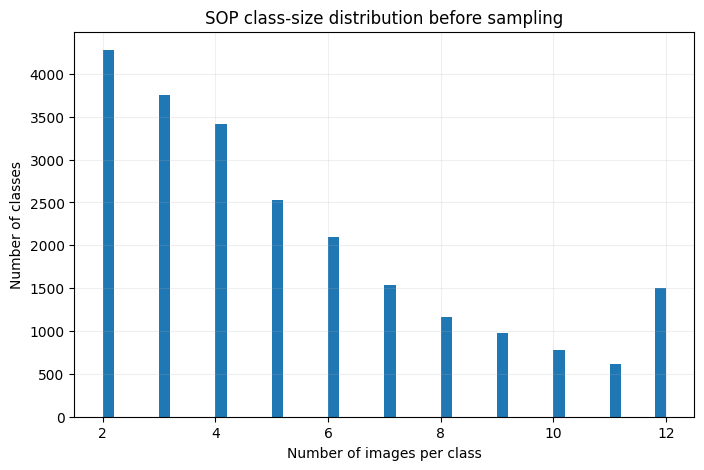

In [29]:
class_stats_before = (
    candidate_df
    .groupby(["class_id", "super_class_id"])
    .size()
    .reset_index(name="n_images")
    .sort_values("n_images", ascending=False)
)

display(class_stats_before.head(20))

plt.figure(figsize=(8, 5))
plt.hist(
    class_stats_before["n_images"],
    bins=50
)
plt.xlabel("Number of images per class")
plt.ylabel("Number of classes")
plt.title("SOP class-size distribution before sampling")
plt.grid(alpha=0.2)
plt.show()

## Cell 11 — Hàm tính allocation cho stratified sampling

In [30]:
def proportional_allocation(
    df,
    target_n,
    group_col="class_id",
    min_per_group=2,
):
    """
    Allocate target_n samples approximately proportional
    to each class size.

    Constraints:
    - each selected class gets at least min_per_group
    - no class receives more samples than it owns
    """

    counts = df[group_col].value_counts().sort_index()

    if min_per_group > 0:
        counts = counts[counts >= min_per_group]

    if len(counts) == 0:
        raise ValueError("Không có class hợp lệ.")

    max_selectable_classes = target_n // min_per_group
    if len(counts) > max_selectable_classes:
        rng = np.random.default_rng(RANDOM_SEED)
        selected_class_ids = rng.choice(counts.index, size=max_selectable_classes, replace=False)
        counts = counts.loc[selected_class_ids].sort_index()

    # Initial proportional allocation
    raw = counts / counts.sum() * target_n

    allocation = np.floor(raw).astype(int)

    # Minimum samples per selected class
    allocation = allocation.clip(lower=min_per_group)

    # Không vượt quá số ảnh thật
    allocation = pd.Series(
        np.minimum(allocation, counts),
        index=counts.index,
        dtype=int
    )

    # Điều chỉnh tổng về đúng target_n
    while allocation.sum() < target_n:
        capacity = counts - allocation
        available = capacity[capacity > 0]

        if len(available) == 0:
            break

        # Ưu tiên class còn thiếu nhiều theo proportional raw target
        deficit = raw - allocation
        candidates = deficit.loc[available.index]

        selected_class = candidates.idxmax()
        allocation.loc[selected_class] += 1

    while allocation.sum() > target_n:
        removable = allocation[
            allocation > min_per_group
        ]

        if len(removable) == 0:
            break

        excess = allocation - raw
        selected_class = excess.loc[
            removable.index
        ].idxmax()

        allocation.loc[selected_class] -= 1

    return counts, allocation


original_counts, allocation = proportional_allocation(
    candidate_df,
    target_n=SAMPLE_N,
    group_col="class_id",
    min_per_group=2 if REQUIRE_MIN_2_IMAGES_PER_CLASS else 1,
)

print("Target:", SAMPLE_N)
print("Allocated:", allocation.sum())
print("Selected classes:", len(allocation))

display(
    pd.DataFrame({
        "original_count": original_counts,
        "allocated_count": allocation,
    }).head(20)
)

Target: 20000
Allocated: 20000
Selected classes: 10000


,original_count,allocated_count
class_id,,
1,8,2
6,10,2
11,3,2
13,3,2
14,6,2
16,4,2
17,10,2
21,2,2
22,2,2


## Cell 12 — Kiểm tra allocation

In [31]:
allocation_check = pd.DataFrame({
    "original_count": original_counts,
    "sample_count": allocation,
})

allocation_check["sample_ratio"] = (
    allocation_check["sample_count"]
    / allocation_check["sample_count"].sum()
)

allocation_check["original_ratio"] = (
    allocation_check["original_count"]
    / allocation_check["original_count"].sum()
)

allocation_check["ratio_diff"] = (
    allocation_check["sample_ratio"]
    - allocation_check["original_ratio"]
)

print("Total allocated:", allocation_check.sample_count.sum())
print(
    "Classes with zero allocation:",
    (allocation_check.sample_count == 0).sum()
)

display(allocation_check.describe())

Total allocated: 20000
Classes with zero allocation: 0


,original_count,sample_count,sample_ratio,original_ratio,ratio_diff
count,10000.000000,10000.0,1.000000e+04,10000.000000,1.000000e+04
mean,5.272600,2.0,1.000000e-04,0.000100,6.938894e-21
std,2.991519,0.0,9.392371e-18,0.000057,5.673707e-05
min,2.000000,2.0,1.000000e-04,0.000038,-1.275917e-04
25%,3.000000,2.0,1.000000e-04,0.000057,-3.276183e-05
50%,4.000000,2.0,1.000000e-04,0.000076,2.413610e-05
75%,7.000000,2.0,1.000000e-04,0.000133,4.310207e-05
max,12.000000,2.0,1.000000e-04,0.000228,6.206805e-05


## Cell 13 — Thực hiện stratified sampling

In [32]:
rng = np.random.default_rng(RANDOM_SEED)

sample_parts = []

for class_id, n_samples in allocation.items():

    class_df = candidate_df[
        candidate_df["class_id"] == class_id
    ]

    selected_indices = rng.choice(
        len(class_df),
        size=int(n_samples),
        replace=False
    )

    selected = class_df.iloc[selected_indices].copy()

    sample_parts.append(selected)

sample_df = pd.concat(
    sample_parts,
    ignore_index=True
)

# Shuffle toàn bộ sample
sample_df = sample_df.sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print("Sample size:", len(sample_df))
print("Sample classes:", sample_df.class_id.nunique())

Sample size: 20000
Sample classes: 10000


## Cell 14 — Kiểm tra sample size và uniqueness

In [33]:
assert len(sample_df) == SAMPLE_N, (
    f"Expected {SAMPLE_N}, got {len(sample_df)}"
)

assert sample_df.image_id.nunique() == len(sample_df), (
    "Duplicate image_id trong sample."
)

print("✓ Sample size đúng:", len(sample_df))
print("✓ Image IDs unique")
print("✓ Classes:", sample_df.class_id.nunique())

✓ Sample size đúng: 20000
✓ Image IDs unique
✓ Classes: 10000


## Cell 15 — So sánh phân bố original vs sampled

In [34]:
sample_counts = sample_df.groupby("class_id").size()

distribution = pd.DataFrame({
    "original_count": original_counts,
    "sample_count": sample_counts,
}).fillna(0)

distribution["original_ratio"] = (
    distribution["original_count"]
    / distribution["original_count"].sum()
)

distribution["sample_ratio"] = (
    distribution["sample_count"]
    / distribution["sample_count"].sum()
)

distribution["ratio_diff"] = (
    distribution["sample_ratio"]
    - distribution["original_ratio"]
)

display(distribution.head(20))

,original_count,sample_count,original_ratio,sample_ratio,ratio_diff
class_id,,,,,
1,8,2,0.000152,0.0001,-0.000052
6,10,2,0.000190,0.0001,-0.000090
11,3,2,0.000057,0.0001,0.000043
13,3,2,0.000057,0.0001,0.000043
14,6,2,0.000114,0.0001,-0.000014
16,4,2,0.000076,0.0001,0.000024
17,10,2,0.000190,0.0001,-0.000090
21,2,2,0.000038,0.0001,0.000062
22,2,2,0.000038,0.0001,0.000062


## Cell 16 — Định lượng mức độ giữ phân bố

In [35]:
# Mean absolute difference giữa tỷ lệ class
mad = distribution["ratio_diff"].abs().mean()

# Maximum absolute difference
max_diff = distribution["ratio_diff"].abs().max()

# Correlation giữa số ảnh original và số ảnh sampled
corr = distribution[
    ["original_count", "sample_count"]
].corr().iloc[0, 1]

print(f"Mean absolute ratio difference : {mad:.8f}")
print(f"Maximum absolute ratio diff   : {max_diff:.8f}")
print(f"Count correlation              : {corr:.6f}")

Mean absolute ratio difference : 0.00004665
Maximum absolute ratio diff   : 0.00012759
Count correlation              : nan


## Cell 17 — Vẽ original vs sampled distribution

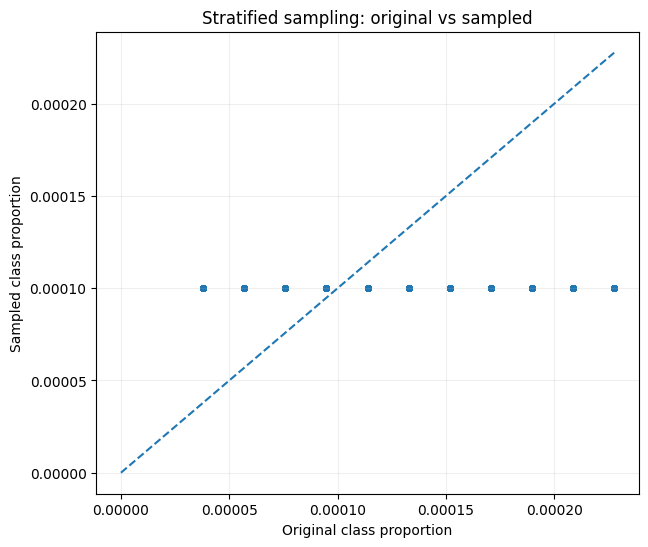

Saved: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/outputs/sampling/sampling_distribution.png


In [36]:
plt.figure(figsize=(7, 6))

plt.scatter(
    distribution["original_ratio"],
    distribution["sample_ratio"],
    s=12
)

mx = max(
    distribution["original_ratio"].max(),
    distribution["sample_ratio"].max()
)

plt.plot(
    [0, mx],
    [0, mx],
    linestyle="--"
)

plt.xlabel("Original class proportion")
plt.ylabel("Sampled class proportion")
plt.title("Stratified sampling: original vs sampled")
plt.grid(alpha=0.2)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig_path = OUTPUT_DIR / "sampling_distribution.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved:", fig_path)

## Cell 18 — Kiểm tra phân bố theo `super_class_id`

In [37]:
super_before = (
    candidate_df.groupby("super_class_id")
    .size()
    .rename("original_count")
)

super_after = (
    sample_df.groupby("super_class_id")
    .size()
    .rename("sample_count")
)

super_dist = pd.concat(
    [super_before, super_after],
    axis=1
).fillna(0)

super_dist["original_ratio"] = (
    super_dist["original_count"]
    / super_dist["original_count"].sum()
)

super_dist["sample_ratio"] = (
    super_dist["sample_count"]
    / super_dist["sample_count"].sum()
)

super_dist["ratio_diff"] = (
    super_dist["sample_ratio"]
    - super_dist["original_ratio"]
)

display(super_dist.sort_values(
    "original_count",
    ascending=False
).head(20))

print(
    "Super-class mean absolute ratio difference:",
    super_dist["ratio_diff"].abs().mean()
)

,original_count,sample_count,original_ratio,sample_ratio,ratio_diff
super_class_id,,,,,
8,13626,2388,0.113500,0.1194,0.005900
7,12530,1874,0.104371,0.0937,-0.010671
3,12071,1936,0.100547,0.0968,-0.003747
2,12068,1752,0.100522,0.0876,-0.012922
11,11108,2106,0.092526,0.1053,0.012774
6,10114,1664,0.084246,0.0832,-0.001046
4,9698,1620,0.080781,0.0810,0.000219
12,8712,1622,0.072568,0.0811,0.008532
10,8386,1566,0.069852,0.0783,0.008448


Super-class mean absolute ratio difference: 0.00810510649463154


## Cell 19 — Kiểm tra train/test source split trong sample

In [38]:
split_distribution = (
    sample_df["source_split"]
    .value_counts()
    .rename_axis("source_split")
    .reset_index(name="count")
)

split_distribution["ratio"] = (
    split_distribution["count"]
    / split_distribution["count"].sum()
)

display(split_distribution)

,source_split,count,ratio
0,train,10190,0.5095
1,test,9810,0.4905


## Cell 20 — Preview ảnh được sampling

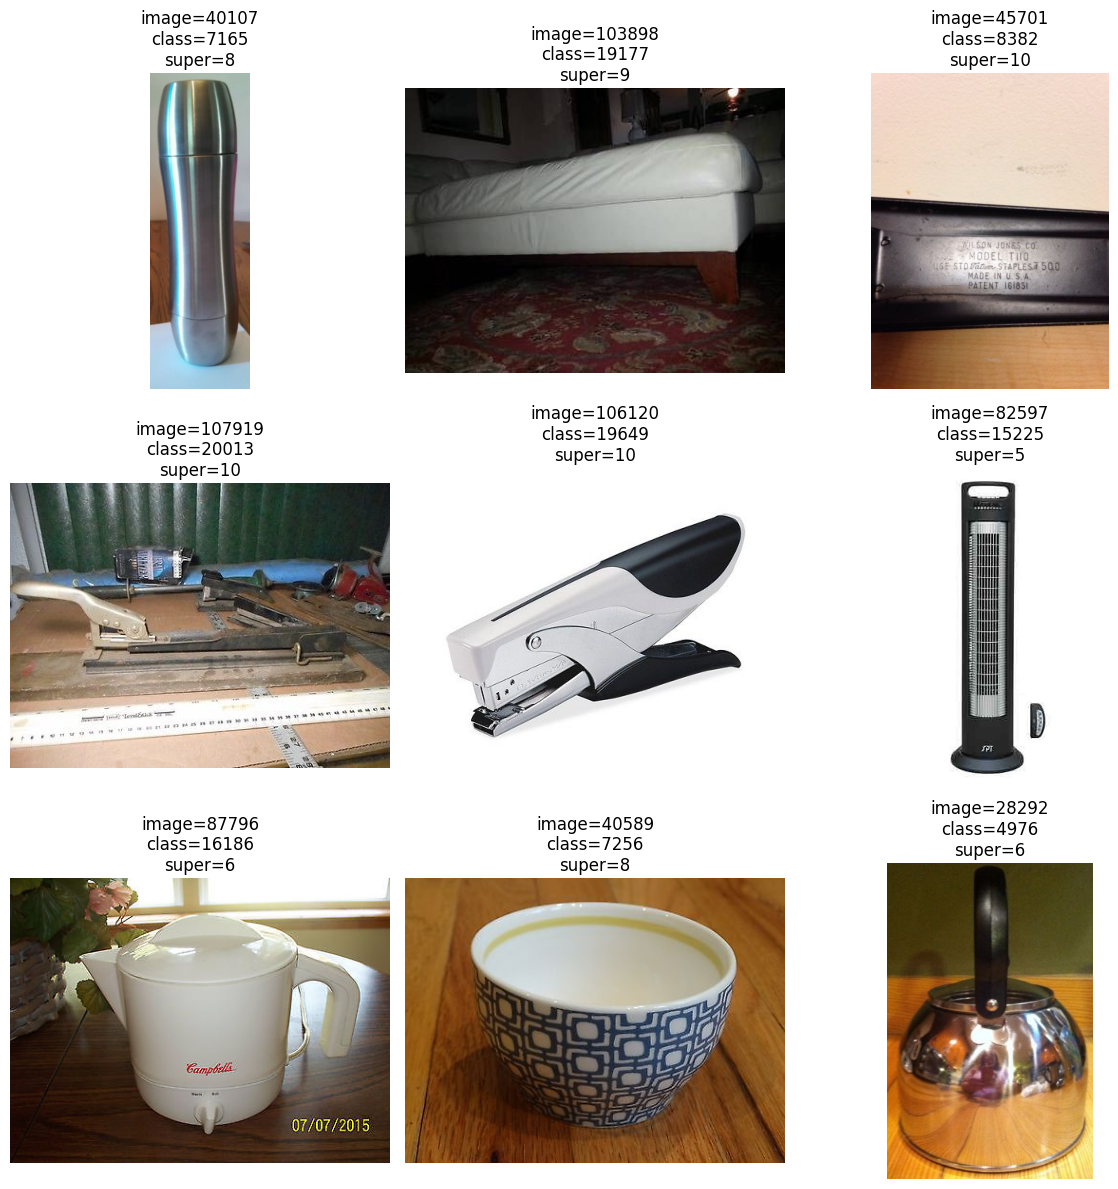

Saved: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/outputs/sampling/sample_preview.png


In [39]:
from PIL import Image

preview = sample_df.sample(
    min(9, len(sample_df)),
    random_state=RANDOM_SEED
)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(preview.iterrows(), start=1):
    ax = plt.subplot(3, 3, i)

    try:
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        ax.imshow(image)

        ax.set_title(
            f"image={row.image_id}\n"
            f"class={row.class_id}\n"
            f"super={row.super_class_id}"
        )

    except Exception as e:
        ax.set_title(f"ERROR\n{e}")

    ax.axis("off")

plt.tight_layout()

preview_path = OUTPUT_DIR / "sample_preview.png"
plt.savefig(
    preview_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", preview_path)

## Cell 21 — Lưu `sop_20k.csv`

In [40]:
SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

sample_output = SPLIT_DIR / "sop_20k.csv"

# Chỉ lưu những field cần thiết cho các notebook tiếp theo.
columns = [
    "image_id",
    "class_id",
    "super_class_id",
    "path",
    "image_path",
    "source_split",
]

sample_df[columns].to_csv(
    sample_output,
    index=False
)

print("Saved:", sample_output)
print("Rows:", len(sample_df))

Saved: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/data/sampled/sop_20k.csv
Rows: 20000


## Cell 22 — Lưu bảng thống kê sampling

In [41]:
distribution_output = (OUTPUT_DIR / "class_distribution.csv")
distribution.reset_index(names="class_id").to_csv(distribution_output,index=False)
print("Saved:", distribution_output)

Saved: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/outputs/sampling/class_distribution.csv


## Cell 23 — Lưu summary JSON

In [42]:
summary = {
    "source": "Stanford Online Products",
    "sampling_method": "proportional stratified sampling",
    "stratification_key": "class_id",
    "original_images": int(len(full_df)),
    "candidate_images": int(len(candidate_df)),
    "sample_images": int(len(sample_df)),
    "original_classes": int(full_df.class_id.nunique()),
    "candidate_classes": int(candidate_df.class_id.nunique()),
    "sample_classes": int(sample_df.class_id.nunique()),
    "random_seed": RANDOM_SEED,
    "min_images_per_selected_class": (
        int(sample_df.groupby("class_id").size().min())
    ),
    "mean_absolute_class_ratio_difference": float(mad),
    "maximum_class_ratio_difference": float(max_diff),
    "class_count_correlation": float(corr),
}

summary_path = OUTPUT_DIR / "sampling_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print(json.dumps(
    summary,
    indent=2,
    ensure_ascii=False
))

print("\nSaved:", summary_path)

{
  "source": "Stanford Online Products",
  "sampling_method": "proportional stratified sampling",
  "stratification_key": "class_id",
  "original_images": 120053,
  "candidate_images": 120053,
  "sample_images": 20000,
  "original_classes": 22634,
  "candidate_classes": 22634,
  "sample_classes": 10000,
  "random_seed": 42,
  "min_images_per_selected_class": 2,
  "mean_absolute_class_ratio_difference": 4.664606531881804e-05,
  "maximum_class_ratio_difference": 0.00012759170048932212,
  "class_count_correlation": NaN
}

Saved: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/outputs/sampling/sampling_summary.json


## Cell 24 — Final validation

Notebook 01 được xem là **hoàn thành** nếu toàn bộ assertion dưới đây pass:

- `sop_20k.csv` có đúng 20,000 ảnh.
- Không duplicate `image_id`.
- Mỗi selected `class_id` có ít nhất 2 ảnh.
- Tất cả image path đều tồn tại nếu bật `CHECK_IMAGE_EXISTS`.
- Phân bố class sau sampling gần với phân bố ban đầu.
- Metadata gốc (`image_id`, `class_id`, `super_class_id`, `path`) được giữ nguyên.

Output này sẽ được notebook 02/03 sử dụng, **không sampling lại**.

In [43]:
# Final validation
saved = pd.read_csv(sample_output)

assert len(saved) == SAMPLE_N
assert saved.image_id.nunique() == SAMPLE_N

if CHECK_IMAGE_EXISTS:
    assert saved.image_path.map(os.path.exists).all()

class_sample_counts = saved.groupby("class_id").size()

if REQUIRE_MIN_2_IMAGES_PER_CLASS:
    assert class_sample_counts.min() >= 2

required_columns = {
    "image_id",
    "class_id",
    "super_class_id",
    "path",
    "image_path",
    "source_split",
}

assert required_columns.issubset(saved.columns)

print("=" * 60)
print("SAMPLING NOTEBOOK COMPLETED SUCCESSFULLY")
print("=" * 60)
print("Output:", sample_output)
print("Images:", len(saved))
print("Classes:", saved.class_id.nunique())
print("Min images/class:", class_sample_counts.min())
print("Max images/class:", class_sample_counts.max())
print("All image paths exist:", saved.image_path.map(os.path.exists).all())

SAMPLING NOTEBOOK COMPLETED SUCCESSFULLY
Output: /kaggle/working/DINOv3-FAISS-HNSW-SOP-VisualProductSearch/data/sampled/sop_20k.csv
Images: 20000
Classes: 10000
Min images/class: 2
Max images/class: 2
All image paths exist: True


# Expected output

Sau khi chạy xong notebook, thư mục nên có:

```text
data/
└── sampled/
    └── sop_20k.csv

outputs/
└── sampling/
    ├── class_distribution.csv
    ├── sampling_summary.json
    ├── sampling_distribution.png
    └── sample_preview.png
```

`notebooks/02_baseline.ipynb` sẽ **đọc `data/sampled/sop_20k.csv`**, không thực hiện sampling lại.

In [44]:
# ==============================================================================
# KAGGLE OUTPUT & RESULTS PREVIEW BLOCK (INDEPENDENT BLOCK)
# ==============================================================================
import os
import shutil
from pathlib import Path
import pandas as pd

IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if IS_KAGGLE:
    print("--- Kaggle Output & Preview ---")
    
    # 1. Print preview
    print("Preview of sop_20k.csv:")
    sop_path = Path("data/sampled/sop_20k.csv")
    if sop_path.exists():
        df = pd.read_csv(sop_path)
        print(f"Shape: {df.shape}")
        print(df.head())
        
    print("\nPreview of sampling_summary.json:")
    summary_path = Path("outputs/sampling/sampling_summary.json")
    if summary_path.exists():
        with open(summary_path, 'r') as f:
            print(f.read())
            
    # 2. Export to /kaggle/working
    print("\nCopying results to Kaggle output directory (/kaggle/working)...")
    dest_dir = Path("/kaggle/working/outputs/sampling")
    dest_dir.mkdir(parents=True, exist_ok=True)
    
    src_dir = Path("outputs/sampling")
    if src_dir.exists():
        for item in src_dir.iterdir():
            if item.is_file():
                shutil.copy(item, dest_dir)
                print(f"Copied {item.name} to {dest_dir}")
                
    dest_splits = Path("/kaggle/working/data/sampled")
    dest_splits.mkdir(parents=True, exist_ok=True)
    if sop_path.exists():
        shutil.copy(sop_path, dest_splits)
        print(f"Copied {sop_path.name} to {dest_splits}")


--- Kaggle Output & Preview ---
Preview of sop_20k.csv:

Preview of sampling_summary.json:

Copying results to Kaggle output directory (/kaggle/working)...
